In [12]:
import tensorflow as tf
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("CPU:", tf.config.list_physical_devices("CPU"))

TensorFlow: 2.21.0
GPU: []
CPU: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [13]:
BASE_PATH = Path(
    r"E:\ediprj\data\datasetHand"
)

TRAIN_PATH = BASE_PATH / "Training"
VAL_PATH = BASE_PATH / "Validation"
TEST_PATH = BASE_PATH / "Testing"

train_csv = TRAIN_PATH / "training_labels.csv"
val_csv = VAL_PATH / "validation_labels.csv"
test_csv = TEST_PATH / "testing_labels.csv"

train_images = TRAIN_PATH / "training_words"
val_images = VAL_PATH / "validation_words"
test_images = TEST_PATH / "testing_words"

In [14]:
print("BASE:", BASE_PATH.exists())

print("Train CSV:", train_csv.exists())
print("Train images:", train_images.exists())

print("Val CSV:", val_csv.exists())
print("Val images:", val_images.exists())

print("Test CSV:", test_csv.exists())
print("Test images:", test_images.exists())

BASE: True
Train CSV: True
Train images: True
Val CSV: True
Val images: True
Test CSV: True
Test images: True


In [15]:
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples:", len(test_df))

print(train_df.head())

Training samples: 3120
Validation samples: 780
Testing samples: 780
   IMAGE MEDICINE_NAME GENERIC_NAME
0  0.png         Aceta  Paracetamol
1  1.png         Aceta  Paracetamol
2  2.png         Aceta  Paracetamol
3  3.png         Aceta  Paracetamol
4  4.png         Aceta  Paracetamol


In [16]:
classes = sorted(train_df["MEDICINE_NAME"].unique())

label_map = {
    name: i
    for i, name in enumerate(classes)
}

train_df["label"] = train_df["MEDICINE_NAME"].map(label_map)
val_df["label"] = val_df["MEDICINE_NAME"].map(label_map)
test_df["label"] = test_df["MEDICINE_NAME"].map(label_map)

NUM_CLASSES = len(classes)

print("Number of classes:", NUM_CLASSES)
print("First 10 classes:")

for i, name in enumerate(classes[:10]):
    print(i, "->", name)

Number of classes: 78
First 10 classes:
0 -> Ace
1 -> Aceta
2 -> Alatrol
3 -> Amodis
4 -> Atrizin
5 -> Axodin
6 -> Az
7 -> Azithrocin
8 -> Azyth
9 -> Bacaid


In [17]:
IMG_HEIGHT = 64
IMG_WIDTH = 256

def preprocess_image(image_path):

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        raise ValueError(
            f"Could not read image: {image_path}"
        )

    # Resize
    image = cv2.resize(
        image,
        (IMG_WIDTH, IMG_HEIGHT)
    )

    # Normalize
    image = image.astype(np.float32) / 255.0

    # Add channel
    image = np.expand_dims(image, axis=-1)

    return image

In [18]:
sample_image = train_images / train_df.iloc[0]["IMAGE"]

print(sample_image)
print("Exists:", sample_image.exists())

image = preprocess_image(sample_image)

print("Shape:", image.shape)
print("Min:", image.min())
print("Max:", image.max())

E:\ediprj\data\datasetHand\Training\training_words\0.png
Exists: True
Shape: (64, 256, 1)
Min: 0.0
Max: 1.0


In [19]:
def load_dataset(dataframe, image_folder):

    X = []
    y = []

    for _, row in tqdm(
        dataframe.iterrows(),
        total=len(dataframe)
    ):

        image_path = image_folder / row["IMAGE"]

        image = preprocess_image(image_path)

        X.append(image)
        y.append(row["label"])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)

    return X, y

In [20]:
X_train, y_train = load_dataset(
    train_df,
    train_images
)

X_val, y_val = load_dataset(
    val_df,
    val_images
)

X_test, y_test = load_dataset(
    test_df,
    test_images
)

100%|██████████| 780/780 [00:00<00:00, 848.07it/s]


In [21]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (3120, 64, 256, 1)
y_train: (3120,)
X_val: (780, 64, 256, 1)
y_val: (780,)
X_test: (780, 64, 256, 1)
y_test: (780,)


In [22]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

NUM_CLASSES = 78

model = keras.Sequential([
    
    layers.Input(shape=(64, 256, 1)),

    # -------------------------
    # Data Augmentation
    # -------------------------
    layers.RandomRotation(0.03),

    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),

    layers.RandomZoom(0.05),

    # -------------------------
    # CNN Block 1
    # -------------------------
    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.20),

    # -------------------------
    # CNN Block 2
    # -------------------------
    layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # -------------------------
    # CNN Block 3
    # -------------------------
    layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    # -------------------------
    # Classification
    # -------------------------
    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.BatchNormalization(),
    layers.Dropout(0.40),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

model.summary()

TensorFlow: 2.21.0
GPU: []


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 64, 256, 1)     │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 64, 256, 1)     │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 64, 256, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 256, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 256, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 128, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 128, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 32, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 32, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 78)             │        10,062 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,654 (471.30 KB)

 Trainable params: 119,950 (468.55 KB)

 Non-trainable params: 704 (2.75 KB)

In [23]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [24]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_prescription_model.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [25]:
history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=50,

    batch_size=16,

    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ],

    verbose=1
)

Epoch 1/50
138/195 ━━━━━━━━━━━━━━━━━━━━ 30s 538ms/step - accuracy: 0.0308 - loss: 4.5060

KeyboardInterrupt: 

In [ ]:
best_train_acc = max(history.history["accuracy"])
best_val_acc = max(history.history["val_accuracy"])

print("Best Training Accuracy:", best_train_acc)
print("Best Validation Accuracy:", best_val_acc)

Best Training Accuracy: 0.48750001192092896
Best Validation Accuracy: 0.4089743494987488


In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    batch_size=16,
    verbose=1
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.1974 - loss: 3.5558

Test Loss: 3.5558011531829834
Test Accuracy: 0.1974359005689621


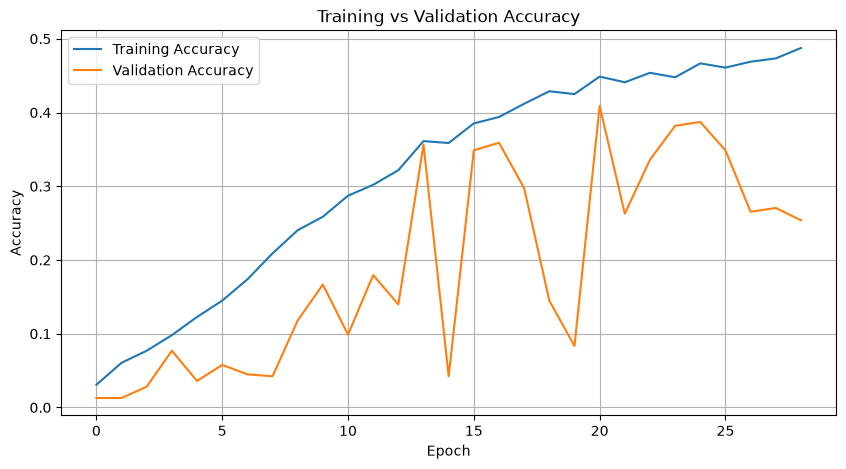

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)
import numpy as np

# Predict
y_prob = model.predict(
    X_test,
    batch_size=16,
    verbose=1
)

y_pred = np.argmax(
    y_prob,
    axis=1
)

print("Predictions generated.")

49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step
Predictions generated.


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.00      0.00      0.00        10
           2       0.00      0.00      0.00        10
           3       0.00      0.00      0.00        10
           4       0.00      0.00      0.00        10
           5       0.00      0.00      0.00        10
           6       0.01      1.00      0.03        10
           7       0.00      0.00      0.00        10
           8       0.00      0.00      0.00        10
           9       0.00      0.00      0.00        10
          10       0.00      0.00      0.00        10
          11       0.00      0.00      0.00        10
          12       0.00      0.00      0.00        10
          13       0.00      0.00      0.00        10
          14       0.00      0.00      0.00        10
          15       0.00      0.00      0.00        10
          16       0.00      0.00      0.00        10
          17       0.00    

In [26]:
import pandas as pd
from pathlib import Path

RX_PATH = Path(r"E:\ediprj\data\RxHandBD-ML")

train_csv = RX_PATH / "Train_Label.csv"
test_csv = RX_PATH / "Test_Label.csv"

train_labels = pd.read_csv(train_csv)
test_labels = pd.read_csv(test_csv)

print("TRAIN")
print(train_labels.shape)
print(train_labels.columns.tolist())
display(train_labels.head(20))

print("\nTEST")
print(test_labels.shape)
print(test_labels.columns.tolist())
display(test_labels.head(20))

TRAIN
(4463, 2)
['Images', 'Text']


,Images,Text
0,P1116.jpg,Dexter
1,P1117.jpg,Clavusef sw
2,P1118.jpg,m-lucas 10
3,P1119.jpg,Dophyllin
4,P1120.jpg,Delfian
5,P1121.jpg,uliv
6,P1122.jpg,Clacef
7,P1123.jpg,Paloxi
8,P1124.jpg,Dominos
9,P1125.jpg,m-lucas 10



TEST
(1115, 2)
['Images', 'Text']


,Images,Text
0,P0001.jpg,Nexcital
1,P0002.jpg,Inderen
2,P0003.jpg,Indever
3,P0004.jpg,Losita
4,P0005.jpg,Rivotril
5,P0006.jpg,Asynta
6,P0007.jpg,Napa
7,P0008.jpg,Econate
8,P0009.jpg,Exeptim
9,P0010.jpg,Napa


In [27]:
print("Unique train labels:")
print(train_labels.nunique())

print("\nUnique test labels:")
print(test_labels.nunique())

Unique train labels:
Images    4463
Text      1456
dtype: int64

Unique test labels:
Images    1115
Text       496
dtype: int64


In [28]:
# Original 78-class medicines
original_medicines = set(
    train_df["MEDICINE_NAME"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# RxHandBD medicines/text
rx_medicines = set(
    train_labels["Text"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Find exact matches
common = original_medicines.intersection(rx_medicines)

print("Original medicines:", len(original_medicines))
print("RxHandBD labels:", len(rx_medicines))
print("Exact matching medicines:", len(common))

print("\nMatching medicines:")
for medicine in sorted(common):
    print(medicine)

Original medicines: 78
RxHandBD labels: 1278
Exact matching medicines: 33

Matching medicines:
ace
alatrol
beklo
bicozin
esonix
esoral
exium
fenadin
fexo
fexofast
filmet
fixal
flamyd
flexibac
flugal
lumona
m-kast
maxima
maxpro
metro
monas
montair
montene
napa
napa extend
nexum
omastin
progut
renova
rivotril
sergel
telfast
vifas


In [29]:
for medicine in sorted(original_medicines):

    matches = [
        text for text in rx_medicines
        if medicine in text or text in medicine
    ]

    if matches:
        print(f"{medicine} -> {matches[:10]}")

ace -> ['clacef', 'calacef', 'ace xr', 'ace power', 'paracetamol', 'ace', 'duracef', 'acemox', 'iracet']
aceta -> ['paracetamol', 'ace']
alatrol -> ['alatrol']
az -> ['omeprazole', 'ligazid', 'autazol', 'metronidazole', 'azinel', 'moumcaze', 'cap. fzsprazo', 'esprazo', 'fzsprazo', 'ceftazidime']
beklo -> ['tab. beklo', 'beklo 10', 'beklo']
bicozin -> ['bicozin']
esonix -> ['esonix', 'es']
esoral -> ['esoral', 'es']
exium -> ['exium', 'exium mups']
fenadin -> ['fexofenadinee', 'fenadin', 'fexofenadine']
fexo -> ['fexo', 'fexofenadinee', 'fexo 120', 'fexocon', 'fexolet m', 'fexofenadine', 'fexofast']
fexofast -> ['fexo', 'fexofast']
filmet -> ['filmet']
fixal -> ['fixal', 'fixalrt']
flamyd -> ['flamyd']
flexibac -> ['flexibac']
flugal -> ['cap. flugal', 'flugal']
ketocon -> ['toco', 'keto']
ketoral -> ['keto']
ketotab -> ['tab', 'keto']
ketozol -> ['keto']
lumona -> ['lumona']
m-kast -> ['m-kast']
maxima -> ['maxima', 'axim']
maxpro -> ['cap. maxpro', 'tab. maxpro', 'maxpro']
metro -> ['

In [30]:
# Exact overlapping medicines
common = original_medicines.intersection(rx_medicines)

rx_counts = (
    train_labels[
        train_labels["Text"]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(common)
    ]["Text"]
    .astype(str)
    .str.strip()
    .str.lower()
    .value_counts()
)

print("Number of matching classes:", len(common))

print("\nRxHandBD samples per matching class:")
print(rx_counts.sort_index())

print("\nTotal additional RxHandBD training images:")
print(rx_counts.sum())

Number of matching classes: 33

RxHandBD samples per matching class:
Text
ace              4
alatrol          1
beklo            5
bicozin          2
esonix           1
esoral           2
exium            3
fenadin          6
fexo            15
fexofast         9
filmet          11
fixal            2
flamyd           6
flexibac         1
flugal          13
lumona           1
m-kast           1
maxima           9
maxpro          12
metro           10
monas           13
montair          2
montene         14
napa           133
napa extend      2
nexum           33
omastin          1
progut           1
renova           6
rivotril        10
sergel           7
telfast          1
vifas            1
Name: count, dtype: int64

Total additional RxHandBD training images:
338


In [31]:
import pandas as pd
from pathlib import Path

# ============================================================
# PATHS
# ============================================================

BASE_PATH = Path(r"E:\ediprj\data")

# Original dataset
ORIGINAL_PATH = BASE_PATH / "datasetHand"

# RxHandBD
RX_PATH = BASE_PATH / "RxHandBD-ML"

# Output
MERGED_PATH = BASE_PATH / "merged_dataset"

MERGED_PATH.mkdir(parents=True, exist_ok=True)


# ============================================================
# LOAD ORIGINAL DATA
# ============================================================

original_train_csv = (
    ORIGINAL_PATH
    / "Training"
    / "training_labels.csv"
)

original_train = pd.read_csv(original_train_csv)

print("Original training samples:", len(original_train))
print("Original classes:", original_train["MEDICINE_NAME"].nunique())


# ============================================================
# LOAD RxHandBD
# ============================================================

rx_train_csv = RX_PATH / "Train_Label.csv"

rx_train = pd.read_csv(rx_train_csv)

print("RxHandBD samples:", len(rx_train))
print("RxHandBD unique labels:", rx_train["Text"].nunique())


# ============================================================
# NORMALIZE LABELS
# ============================================================

original_train["medicine_clean"] = (
    original_train["MEDICINE_NAME"]
    .astype(str)
    .str.strip()
    .str.lower()
)

rx_train["medicine_clean"] = (
    rx_train["Text"]
    .astype(str)
    .str.strip()
    .str.lower()
)


# ============================================================
# FIND EXACT MATCHES
# ============================================================

original_medicines = set(
    original_train["medicine_clean"]
)

rx_medicines = set(
    rx_train["medicine_clean"]
)

common = original_medicines.intersection(
    rx_medicines
)

print("\nExact matching classes:", len(common))
print(sorted(common))


# ============================================================
# FILTER RxHandBD
# ============================================================

rx_matching = rx_train[
    rx_train["medicine_clean"].isin(common)
].copy()

print("\nRxHandBD matching samples:", len(rx_matching))


# ============================================================
# DISPLAY COUNTS
# ============================================================

print("\nSamples per matching class:")

print(
    rx_matching["medicine_clean"]
    .value_counts()
    .sort_index()
)

Original training samples: 3120
Original classes: 78
RxHandBD samples: 4463
RxHandBD unique labels: 1456

Exact matching classes: 33
['ace', 'alatrol', 'beklo', 'bicozin', 'esonix', 'esoral', 'exium', 'fenadin', 'fexo', 'fexofast', 'filmet', 'fixal', 'flamyd', 'flexibac', 'flugal', 'lumona', 'm-kast', 'maxima', 'maxpro', 'metro', 'monas', 'montair', 'montene', 'napa', 'napa extend', 'nexum', 'omastin', 'progut', 'renova', 'rivotril', 'sergel', 'telfast', 'vifas']

RxHandBD matching samples: 338

Samples per matching class:
medicine_clean
ace              4
alatrol          1
beklo            5
bicozin          2
esonix           1
esoral           2
exium            3
fenadin          6
fexo            15
fexofast         9
filmet          11
fixal            2
flamyd           6
flexibac         1
flugal          13
lumona           1
m-kast           1
maxima           9
maxpro          12
metro           10
monas           13
montair          2
montene         14
napa           133


In [32]:
# ============================================================
# ORIGINAL DATA
# ============================================================

original_merged = original_train[
    ["IMAGE", "MEDICINE_NAME", "GENERIC_NAME"]
].copy()

original_merged["source"] = "original"


# ============================================================
# RxHandBD DATA
# ============================================================

# Map lowercase medicine name back to original
# medicine spelling
medicine_mapping = (
    original_train[
        ["medicine_clean", "MEDICINE_NAME", "GENERIC_NAME"]
    ]
    .drop_duplicates("medicine_clean")
)

rx_matching = rx_matching.merge(
    medicine_mapping,
    on="medicine_clean",
    how="left"
)

rx_merged = rx_matching[
    ["Images", "MEDICINE_NAME", "GENERIC_NAME"]
].copy()

rx_merged = rx_merged.rename(
    columns={"Images": "IMAGE"}
)

rx_merged["source"] = "RxHandBD"


# ============================================================
# COMBINE
# ============================================================

merged_df = pd.concat(
    [original_merged, rx_merged],
    ignore_index=True
)


print("====================================")
print("MERGED DATASET")
print("====================================")

print("Total samples:", len(merged_df))

print(
    "Total classes:",
    merged_df["MEDICINE_NAME"].nunique()
)

print(
    "Original samples:",
    (merged_df["source"] == "original").sum()
)

print(
    "RxHandBD samples:",
    (merged_df["source"] == "RxHandBD").sum()
)

print("\nSamples per class:")
print(
    merged_df["MEDICINE_NAME"]
    .value_counts()
    .sort_index()
)

MERGED DATASET
Total samples: 3458
Total classes: 78
Original samples: 3120
RxHandBD samples: 338

Samples per class:
MEDICINE_NAME
Ace         44
Aceta       40
Alatrol     41
Amodis      40
Atrizin     40
            ..
Telfast     41
Tridosil    40
Trilock     40
Vifas       41
Zithrin     40
Name: count, Length: 78, dtype: int64


In [ ]:
# ============================================================
# ADD ABSOLUTE IMAGE PATH
# ============================================================

merged_df.loc[
    merged_df["source"] == "original",
    "IMAGE_PATH"
] = merged_df.loc[
    merged_df["source"] == "original",
    "IMAGE"
].apply(
    lambda x: str(
        ORIGINAL_PATH
        / "Training"
        / "training_words"
        / x
    )
)


merged_df.loc[
    merged_df["source"] == "RxHandBD",
    "IMAGE_PATH"
] = merged_df.loc[
    merged_df["source"] == "RxHandBD",
    "IMAGE"
].apply(
    lambda x: str(
        RX_PATH
        / "Train_Set"
        / x
    )
)


print(merged_df.head())

print("\nExample original path:")
print(
    merged_df[
        merged_df["source"] == "original"
    ]["IMAGE_PATH"].iloc[0]
)

print("\nExample RxHandBD path:")
print(
    merged_df[
        merged_df["source"] == "RxHandBD"
    ]["IMAGE_PATH"].iloc[0]
)

   IMAGE MEDICINE_NAME GENERIC_NAME    source  \
0  0.png         Aceta  Paracetamol  original   
1  1.png         Aceta  Paracetamol  original   
2  2.png         Aceta  Paracetamol  original   
3  3.png         Aceta  Paracetamol  original   
4  4.png         Aceta  Paracetamol  original   

                                          IMAGE_PATH  
0  E:\ediprj\data\datasetHand\Training\training_w...  
1  E:\ediprj\data\datasetHand\Training\training_w...  
2  E:\ediprj\data\datasetHand\Training\training_w...  
3  E:\ediprj\data\datasetHand\Training\training_w...  
4  E:\ediprj\data\datasetHand\Training\training_w...  

Example original path:
E:\ediprj\data\datasetHand\Training\training_words\0.png

Example RxHandBD path:
E:\ediprj\data\RxHandBD-ML\Train_Set\P1138.jpg


In [33]:
import os

merged_df["exists"] = merged_df["IMAGE_PATH"].apply(
    os.path.exists
)

print("Total images:", len(merged_df))

print(
    "Images found:",
    merged_df["exists"].sum()
)

print(
    "Images missing:",
    (~merged_df["exists"]).sum()
)

if (~merged_df["exists"]).sum() > 0:

    print("\nMissing images:")

    display(
        merged_df[
            ~merged_df["exists"]
        ][
            ["IMAGE", "MEDICINE_NAME", "source", "IMAGE_PATH"]
        ].head(20)
    )

KeyError: 'IMAGE_PATH'

In [34]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

merged_df["label"] = label_encoder.fit_transform(
    merged_df["MEDICINE_NAME"]
)

NUM_CLASSES = len(label_encoder.classes_)

print("Number of classes:", NUM_CLASSES)
print("Classes:", label_encoder.classes_)

Number of classes: 78
Classes: ['Ace' 'Aceta' 'Alatrol' 'Amodis' 'Atrizin' 'Axodin' 'Az' 'Azithrocin'
 'Azyth' 'Bacaid' 'Backtone' 'Baclofen' 'Baclon' 'Bacmax' 'Beklo'
 'Bicozin' 'Canazole' 'Candinil' 'Cetisoft' 'Conaz' 'Dancel' 'Denixil'
 'Diflu' 'Dinafex' 'Disopan' 'Esonix' 'Esoral' 'Etizin' 'Exium' 'Fenadin'
 'Fexo' 'Fexofast' 'Filmet' 'Fixal' 'Flamyd' 'Flexibac' 'Flexilax'
 'Flugal' 'Ketocon' 'Ketoral' 'Ketotab' 'Ketozol' 'Leptic' 'Lucan-R'
 'Lumona' 'M-Kast' 'Maxima' 'Maxpro' 'Metro' 'Metsina' 'Monas' 'Montair'
 'Montene' 'Montex' 'Napa' 'Napa Extend' 'Nexcap' 'Nexum' 'Nidazyl'
 'Nizoder' 'Odmon' 'Omastin' 'Opton' 'Progut' 'Provair' 'Renova' 'Rhinil'
 'Ritch' 'Rivotril' 'Romycin' 'Rozith' 'Sergel' 'Tamen' 'Telfast'
 'Tridosil' 'Trilock' 'Vifas' 'Zithrin']


In [35]:
from sklearn.model_selection import train_test_split

# First: 80% train, 20% temporary
train_df, temp_df = train_test_split(
    merged_df,
    test_size=0.20,
    stratify=merged_df["label"],
    random_state=42
)

# Then: split temporary into 10% validation and 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 2766
Validation: 346
Testing: 346


In [36]:
print("Training classes:", train_df["label"].nunique())
print("Validation classes:", val_df["label"].nunique())
print("Testing classes:", test_df["label"].nunique())

Training classes: 78
Validation classes: 78
Testing classes: 78


In [ ]:
print("Training class distribution:")
print(train_df["MEDICINE_NAME"].value_counts().sort_index())

print("\nValidation class distribution:")
print(val_df["MEDICINE_NAME"].value_counts().sort_index())

print("\nTest class distribution:")
print(test_df["MEDICINE_NAME"].value_counts().sort_index())

Training class distribution:
MEDICINE_NAME
Ace         35
Aceta       32
Alatrol     33
Amodis      32
Atrizin     32
            ..
Telfast     33
Tridosil    32
Trilock     32
Vifas       33
Zithrin     32
Name: count, Length: 78, dtype: int64

Validation class distribution:
MEDICINE_NAME
Ace         5
Aceta       4
Alatrol     4
Amodis      4
Atrizin     4
           ..
Telfast     4
Tridosil    4
Trilock     4
Vifas       4
Zithrin     4
Name: count, Length: 78, dtype: int64

Test class distribution:
MEDICINE_NAME
Ace         4
Aceta       4
Alatrol     4
Amodis      4
Atrizin     4
           ..
Telfast     4
Tridosil    4
Trilock     4
Vifas       4
Zithrin     4
Name: count, Length: 78, dtype: int64


In [37]:
import tensorflow as tf
import numpy as np

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [38]:
def load_image(path, label):
    # Read image
    image = tf.io.read_file(path)

    # Decode grayscale image
    image = tf.image.decode_image(
        image,
        channels=1,
        expand_animations=False
    )

    # Convert uint8 → float32
    image = tf.image.convert_image_dtype(
        image,
        tf.float32
    )

    # Resize
    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    # Convert grayscale → RGB
    image = tf.image.grayscale_to_rgb(image)

    return image, label

In [40]:
train_paths = train_df["IMAGE_PATH"].values
train_labels = train_df["label"].values

val_paths = val_df["IMAGE_PATH"].values
val_labels = val_df["label"].values

test_paths = test_df["IMAGE_PATH"].values
test_labels = test_df["label"].values


train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

KeyError: 'IMAGE_PATH'

In [ ]:
train_ds = (
    train_ds
    .shuffle(
        buffer_size=len(train_df),
        seed=42
    )
    .map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [ ]:
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Image min:", tf.reduce_min(images).numpy())
print("Image max:", tf.reduce_max(images).numpy())

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Image dtype: <dtype: 'float32'>
Image min: 0.0
Image max: 1.0


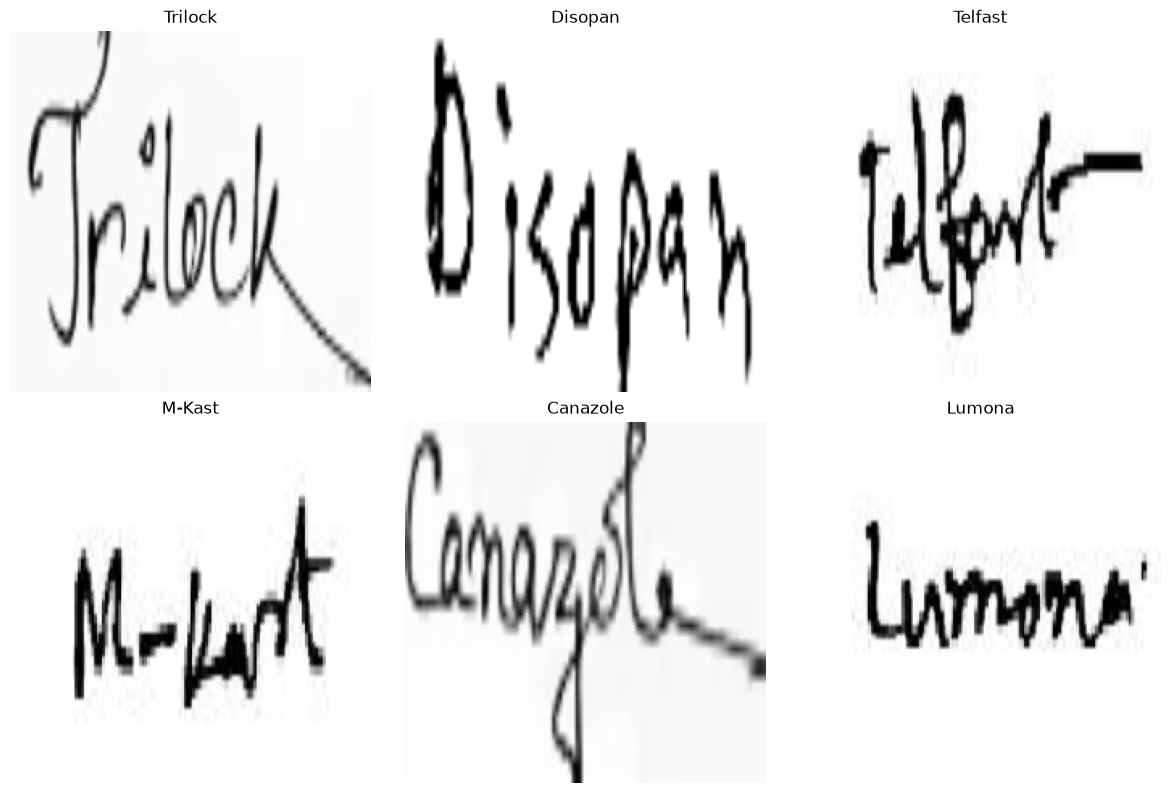

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i in range(6):
    plt.subplot(2, 3, i + 1)

    plt.imshow(images[i].numpy())

    label = labels[i].numpy()

    plt.title(
        label_encoder.inverse_transform([label])[0]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

NUM_CLASSES = 78

# MobileNetV2 pretrained on ImageNet
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers initially
base_model.trainable = False

model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    layers.RandomRotation(0.03),
    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),
    layers.RandomZoom(0.05),

    # MobileNetV2 preprocessing
    layers.Rescaling(
        scale=2.0,
        offset=-1.0
    ),

    # Pretrained feature extractor
    base_model,

    # Classification
    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.4),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_1            │ (None, 224, 224, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 78)             │        10,062 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,432,014 (9.28 MB)

 Trainable params: 174,030 (679.80 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=7,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_mobilenetv2.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ],
    verbose=1
)

Epoch 1/30


e:\ediprj\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.0604 - loss: 4.3016
Epoch 1: val_accuracy improved from None to 0.07225, saving model to best_mobilenetv2.keras

Epoch 1: finished saving model to best_mobilenetv2.keras
173/173 ━━━━━━━━━━━━━━━━━━━━ 121s 669ms/step - accuracy: 0.0604 - loss: 4.3016 - val_accuracy: 0.0723 - val_loss: 4.1028 - learning_rate: 0.0010
Epoch 2/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.0998 - loss: 3.8876
Epoch 2: val_accuracy improved from 0.07225 to 0.13584, saving model to best_mobilenetv2.keras

Epoch 2: finished saving model to best_mobilenetv2.keras
173/173 ━━━━━━━━━━━━━━━━━━━━ 105s 607ms/step - accuracy: 0.0998 - loss: 3.8876 - val_accuracy: 0.1358 - val_loss: 3.7025 - learning_rate: 0.0010
Epoch 3/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.1674 - loss: 3.5001
Epoch 3: val_accuracy improved from 0.13584 to 0.22543, saving model to best_mobilenetv2.keras

Epoch 3: finished saving model to best_mobilenetv2.keras
1

In [ ]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("\n==============================")
print("FINAL TEST RESULTS")
print("==============================")

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 592ms/step - accuracy: 0.5983 - loss: 1.4806

FINAL TEST RESULTS
Test Loss: 1.4805558919906616
Test Accuracy: 0.5982658863067627


In [ ]:
import numpy as np

# Predict probabilities
y_prob = model.predict(test_ds, verbose=1)

# Convert probabilities → predicted class
y_pred = np.argmax(y_prob, axis=1)

# True labels
y_true = np.concatenate([
    y.numpy() for _, y in test_ds
])

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 741ms/step
y_true shape: (346,)
y_pred shape: (346,)


In [ ]:
from sklearn.metrics import classification_report

class_names = label_encoder.classes_

report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

         Ace       0.67      1.00      0.80         4
       Aceta       0.67      0.50      0.57         4
     Alatrol       0.60      0.75      0.67         4
      Amodis       0.67      0.50      0.57         4
     Atrizin       0.33      0.50      0.40         4
      Axodin       1.00      0.50      0.67         4
          Az       0.80      1.00      0.89         4
  Azithrocin       0.29      0.50      0.36         4
       Azyth       0.75      0.75      0.75         4
      Bacaid       0.50      0.75      0.60         4
    Backtone       1.00      0.50      0.67         4
    Baclofen       1.00      0.50      0.67         4
      Baclon       1.00      0.50      0.67         4
      Bacmax       0.67      0.50      0.57         4
       Beklo       0.62      1.00      0.77         5
     Bicozin       1.00      0.75      0.86         4
    Canazole       0.50      1.00      0.67         4
    Candinil       0.67    

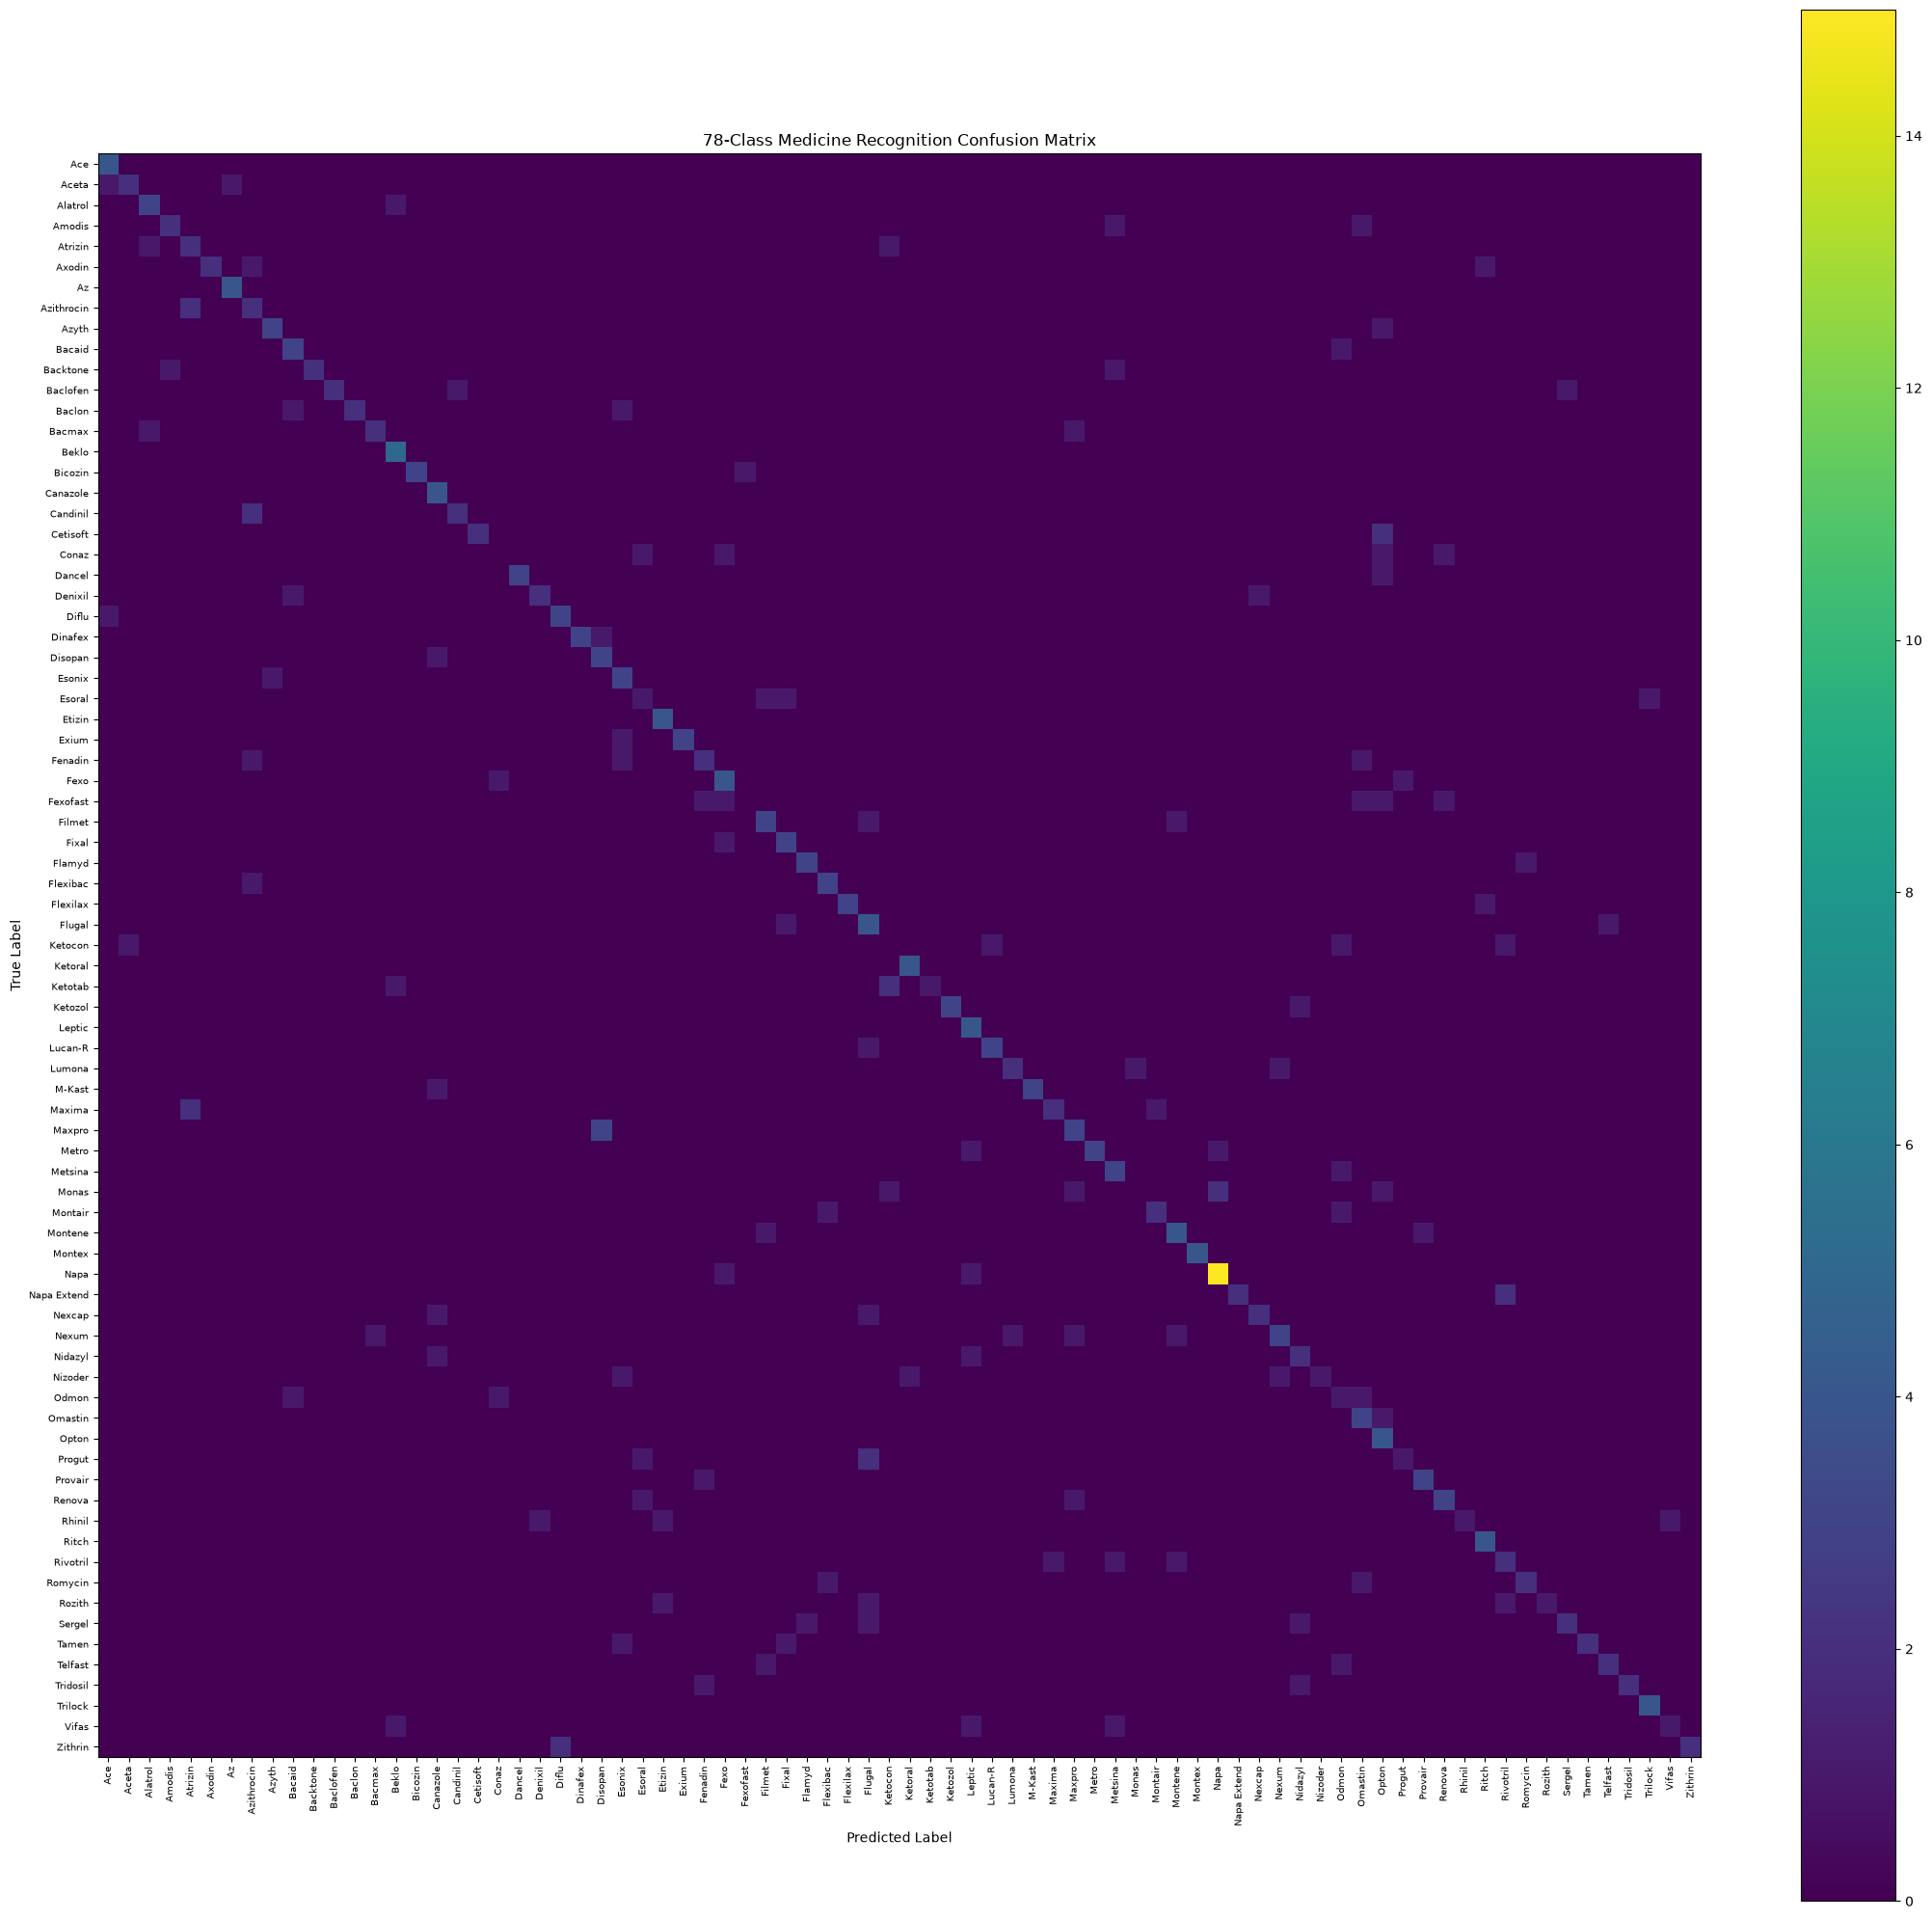

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(len(class_names))
)

plt.figure(figsize=(22, 20))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=90,
    fontsize=7
)

plt.yticks(
    np.arange(len(class_names)),
    class_names,
    fontsize=7
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("78-Class Medicine Recognition Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
cm_no_diag = cm.copy()

# Remove correct predictions
np.fill_diagonal(cm_no_diag, 0)

# Find strongest confusion pairs
indices = np.argsort(
    cm_no_diag.ravel()
)[::-1]

print("Top confusion pairs:\n")

count = 0

for index in indices:
    true_class, pred_class = np.unravel_index(
        index,
        cm_no_diag.shape
    )

    value = cm_no_diag[true_class, pred_class]

    if value == 0:
        break

    print(
        f"{class_names[true_class]:20s}"
        f" → "
        f"{class_names[pred_class]:20s}"
        f": {value}"
    )

    count += 1

    if count == 20:
        break

Top confusion pairs:

Maxpro               → Disopan             : 3
Ketotab              → Ketocon             : 2
Napa Extend          → Rivotril            : 2
Zithrin              → Diflu               : 2
Monas                → Napa                : 2
Maxima               → Atrizin             : 2
Progut               → Flugal              : 2
Cetisoft             → Opton               : 2
Candinil             → Azithrocin          : 2
Azithrocin           → Atrizin             : 2
Sergel               → Flamyd              : 1
Vifas                → Beklo               : 1
Nexcap               → Canazole            : 1
Rhinil               → Denixil             : 1
Nexum                → Lumona              : 1
Montair              → Odmon               : 1
Rivotril             → Montene             : 1
Napa                 → Fexo                : 1
Rivotril             → Metsina             : 1
Nexum                → Bacmax              : 1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get test images and labels
test_images_list = []
test_labels_list = []

for batch_images, batch_labels in test_ds:
    test_images_list.append(batch_images.numpy())
    test_labels_list.append(batch_labels.numpy())

test_images_np = np.concatenate(test_images_list)
test_labels_np = np.concatenate(test_labels_list)

print("Test images:", test_images_np.shape)
print("Test labels:", test_labels_np.shape)

NameError: name 'test_ds' is not defined